# Replication Guide: Compare Feature Explanation Types

## Goal

Compare three explanation **types**: **none**, **feature importance**, and **signed feature attribution**. This is not a comparison between explanation algorithms such as SHAP and LIME.

## Participant task

Participants view five Wine Quality features and predict the AI label. They complete 10 training trials with feedback, followed by 20 testing trials with or without an explanation.

## Study design

- **Between participants:** explanation type (`none`, `importance`, `attribution`)
- **Within participants:** explanation presence (`without`, `with`)
- **Primary outcome:** forward-simulation accuracy
- **Virtual baseline:** KNN trained on each participant's training trials

For the `none` condition, both presence levels show no explanation and serve as the control.

## Steps

1. Define the variables.
2. Create and review the participant protocol.
3. Prepare the dataset.
4. Train the AI.
5. Create balanced trials.
6. Generate importance and attribution displays.
7. Configure the baseline and preview one participant.
8. Run and save the virtual study.
9. Plot accuracy against explanation type and explanation presence.

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd

repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'src' / 'api.py').exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.api import xaikitTest
from src.xai_adapter.api import (
    generate_ai_prediction_table,
    generate_xai_explanation_tables,
    init_explanation_run,
)

SEED = 42
BASELINE_MODEL = 'knn'  # knn, decision_tree, logistic_regression, or mlp
OUTPUT_DIR = Path(os.environ.get(
    'XAIKIT_TUTORIAL_OUTPUT_DIR',
    repo_root / 'tutorials' / 'feature_explanation_replication_output',
))

## 1. Configure the study

Set the explanation type, explanation presence, task, outcome, and participant journey.

In [2]:
study = xaikitTest('feature_explanation_replication', output_dir=OUTPUT_DIR)
study.add_iv('xai_type', 'between', ['none', 'importance', 'attribution'])
# Platform field for explanation presence during testing.
study.add_iv('tested_w_xai', 'within', [False, True], randomization='trial')
study.add_cv('user_task', ['forward_simulation'])
study.add_cv('num_attributes_shown', [5])
study.add_dv('forward_accuracy', ['continuous'])
study.validate_design()


IV configuration:
  xai_type             type=between  randomization=-     levels=['none', 'importance', 'attribution']
  tested_w_xai         type=within   randomization=trial levels=[False, True]

CVs: ['user_task', 'num_attributes_shown']
DVs: ['forward_accuracy']


({'xai_type': {'type': 'between',
   'levels': ['none', 'importance', 'attribution']},
  'tested_w_xai': {'type': 'within',
   'levels': [False, True],
   'randomization': 'trial'}},
 {'user_task': ['forward_simulation'], 'num_attributes_shown': [5]},
 {'forward_accuracy': ['continuous']})

## 2. Create the participant protocol

Define the research questions and the order participants will follow.

In [3]:
study.set_study_protocol(
    study_title='Learning from feature explanations',
    research_questions=[
        'Does explanation type change forward-simulation accuracy?',
        'Does explanation presence during testing change accuracy?',
    ],
    study_summary='Participants train with feedback, then predict AI outputs with or without an explanation.',
    consent_text='Replace with the approved consent and data-handling information.',
    start_survey_questions=['How familiar are you with AI systems?'],
    end_survey_questions=['How helpful was the display?'],
    procedure_steps=[
        {'title': 'Consent', 'kind': 'consent'},
        {'title': 'Background survey', 'kind': 'survey'},
        {'title': 'Training', 'kind': 'practice'},
        {'title': 'Testing', 'kind': 'trials'},
        {'title': 'End survey', 'kind': 'survey'},
        {'title': 'Debrief', 'kind': 'debrief'},
    ],
)

### Review the protocol

Use the editor to revise the participant-facing text before generating trials.

In [4]:
protocol_editor = study.edit_study_protocol()

## 3. Prepare the dataset

Load five Wine Quality features with a reproducible train/test split.

In [5]:
data = study.prepare_dataset(
    'wine_quality',
    feature_cols=['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH'],
    rank_features_by_target=False,
    model_type='mlp',
    test_size=0.4,
    random_state=SEED,
)

Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH']
Encoding  : one-hot
Train set : 959 samples  (60%)
Test set  : 640 samples  (40%)
Class balance (train) -> class 0: 829
Class balance (train) -> class 1: 130
First test instanceIds: [1188, 902, 818, 38, 1255, 496, 947, 861, 839, 1559]


## 4. Train the AI

Train the model whose predictions participants will learn.

In [6]:
study.train_AI_model(
    model_type='mlp',
    target_metric='accuracy',
    target_score=0.90,
    max_epochs=1000,
    check_every_epochs=10,
    batch_size=100,
    verbose=False,
)
display(study.training_summary_table())

,target_metric,target_score,final_score,epochs,batch_size,reached_target,target_accuracy,final_accuracy,model_type,dataset
0,accuracy,0.9,0.905109,300,100,True,0.9,0.905109,mlp,wine_quality


## 5. Create balanced trials

Give each participant 10 training and 20 testing trials, balanced across both AI labels.

In [7]:
trial_result = study.generate_trials(
    participants_per_between_condition=8,
    num_training=10,
    num_testing=20,
    balance_by_ai_prediction=True,
    output_dir='trials',
    seed=SEED,
    preview_rows=4,
)
trials = pd.DataFrame(trial_result.trials)
display(trials.head())

Counterbalancing strategy: complete_counterbalancing
Participant assignments: 24 total
Instance pool rows: 300
Trial rows: 720
Exported trial artifacts:
  CSV     : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output/trials/trials.csv
  JSON    : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output/trials/trials.json
  Summary : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output/trials/design_summary.json

Previewing first 4 trial rows:
{'participantId': 1, 'trialId': 1, 'phase': 'training', 'phaseTrialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'single_condition', 'xai_type': 'none', 'dataId': 'wine_quality', 'instanceId': '1090', 'sampled_ai_prediction': 1}
{'participantId': 1, 'trialId': 2, 'phase': 'training', 'phaseTrialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'single_condition', 'xai_t

,participantId,trialId,block,trialWithinBlock,withinCondition,xai_type,dataId,instanceId,CV_user_task_levels,CV_num_attributes_shown_levels,phase,phaseTrialId,sampled_ai_prediction,tested_w_xai
0,1,1,1,1,single_condition,none,wine_quality,1090,forward_simulation,5,training,1,1,NaN
1,1,2,1,2,single_condition,none,wine_quality,550,forward_simulation,5,training,2,0,NaN
2,1,3,1,3,single_condition,none,wine_quality,1116,forward_simulation,5,training,3,0,NaN
3,1,4,1,4,single_condition,none,wine_quality,1406,forward_simulation,5,training,4,1,NaN
4,1,5,1,5,single_condition,none,wine_quality,375,forward_simulation,5,training,5,1,NaN


### Check trial balance

The minimum and maximum should match within each phase and AI label.

In [8]:
balance_audit = (
    trials.groupby(['participantId', 'phase', 'sampled_ai_prediction'])
    .size().rename('trials').reset_index()
    .groupby(['phase', 'sampled_ai_prediction'])['trials']
    .agg(['min', 'max']).reset_index()
)
display(balance_audit)

,phase,sampled_ai_prediction,min,max
0,testing,0,10,10
1,testing,1,10,10
2,training,0,5,5
3,training,1,5,5


## 6. Generate the explanation types

Use one LIME explanation to create both displays: attribution keeps the signed values, while importance uses their absolute values. This keeps the comparison focused on explanation **type**, not algorithm.

In [9]:
explanation_present = (
    ~trials['xai_type'].astype(str).str.lower().isin(['none', 'no_xai', 'control'])
    & (
        trials['phase'].eq('training')
        | trials['tested_w_xai'].fillna(False).astype(bool)
    )
)
explanation_ids = list(dict.fromkeys(
    trials.loc[explanation_present, 'instanceId'].astype(int).tolist()
))
print(f'Explanation instances: {len(explanation_ids)}')

Explanation instances: 222


/var/folders/96/n6tgn0rs16bfp1cm36gy56hh0000gn/T/ipykernel_16646/2006977048.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | trials['tested_w_xai'].fillna(False).astype(bool)


### Generate one base explanation

LIME supplies the signed feature values used by both explanation types.

In [10]:
explanation_config = init_explanation_run(
    data=data,
    iv_config={'xai_method': {'levels': ['lime']}},
    trained_ai_model=study.trained_ai_model,
    model_name=study.model_name,
    output_dir=OUTPUT_DIR / 'explanations',
    target=1,
    method_kwargs={'lime': {'num_samples': 1000}},
    instance_ids=explanation_ids,
    predictions_by_instance=study.ai_predictions_by_instance,
)
_, explanation_tables = generate_xai_explanation_tables(explanation_config)
prediction_path, prediction_df = generate_ai_prediction_table(explanation_config)


Generating explanations for xai method: lime
  Sampled instances: 222
  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output/explanations/lime_mlp_wine_quality.csv shape=(222, 12)

Saved complete AI prediction table: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output/explanations/predictions_mlp_wine_quality.csv shape=(1599, 5)


### Build importance and attribution

Keep signs for attribution and take absolute values for importance.

In [11]:
attribution_df = explanation_tables[0].copy()
attribution_df['expMethod'] = 'attribution'

importance_df = attribution_df.copy()
importance_df['expMethod'] = 'importance'
value_cols = [c for c in importance_df if c.startswith('a') and c.endswith('_i')]
importance_df[value_cols] = importance_df[value_cols].abs()

### Combine the trial information

Store predictions and both explanation types in one pool for preview and simulation.

In [12]:
prediction_pool = pd.concat(
    [prediction_df, attribution_df, importance_df],
    ignore_index=True,
    sort=False,
)
study.prediction_table_path = prediction_path
study.prediction_table = prediction_df
study.combined_explanations = prediction_pool
display(prediction_pool['expMethod'].value_counts().rename('rows').to_frame())

,rows
expMethod,
__prediction_only__,1599
attribution,222
importance,222


## 7. Configure the baseline and preview the study

KNN is a nearest-example baseline that learns from the training trials. Preview one participant to check training feedback and testing with or without explanations.

In [29]:
study.set_cognitive_model(
    cognitive_model_id=BASELINE_MODEL,
    model_kwargs={'n_neighbors': 6} if BASELINE_MODEL == 'knn' else {},
)

### Preview one participant

Use an attribution participant to check signed explanations and explanation presence.

ipywidgets unavailable. Showing HTML Back/Next preview.


participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,1,training,1293,attribution,False,0
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,2,training,1162,attribution,False,1
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,3,training,455,attribution,False,1
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,4,training,467,attribution,False,1
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,5,training,1178,attribution,False,0
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction

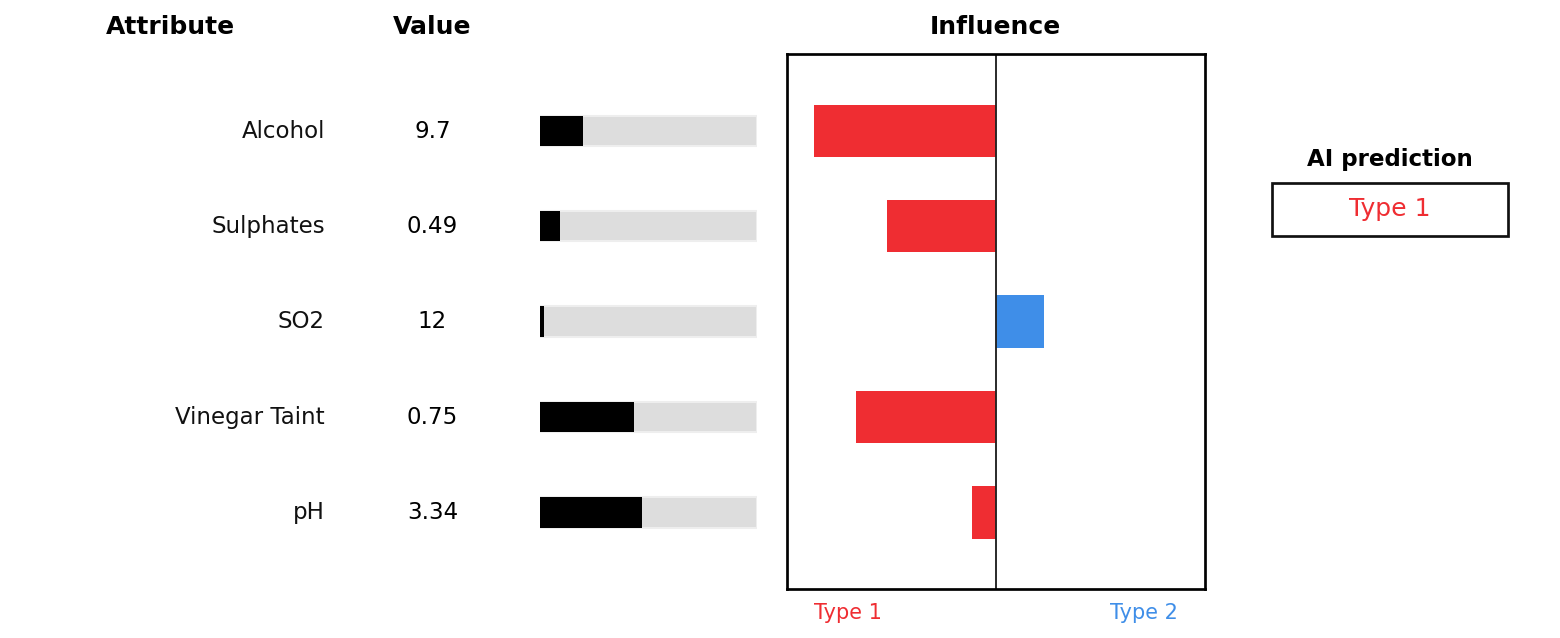
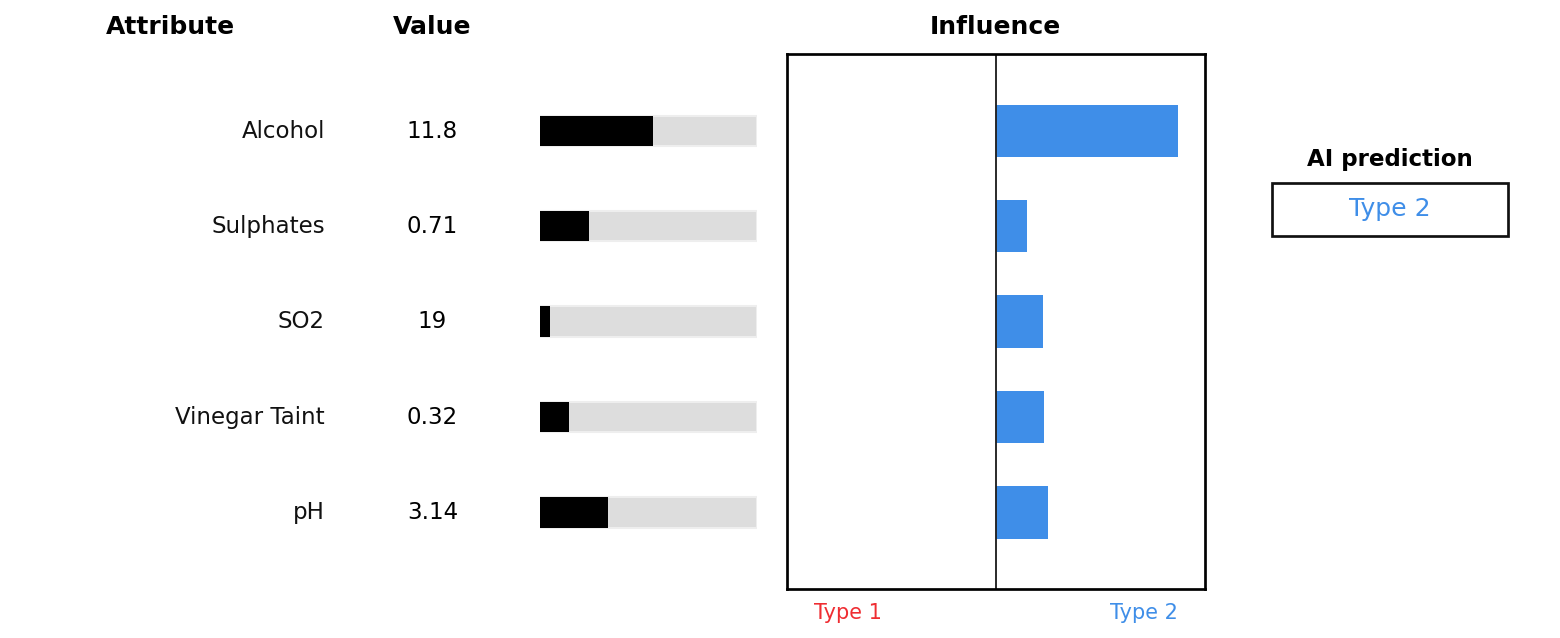
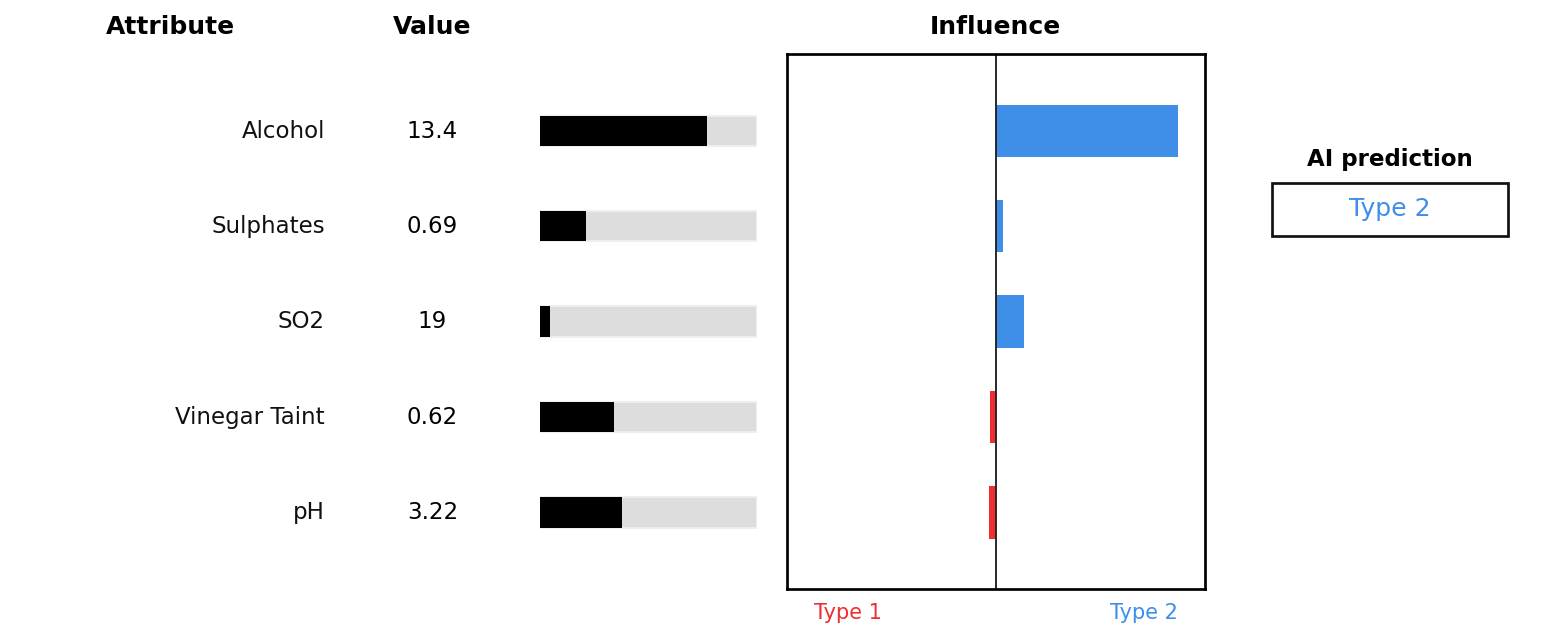
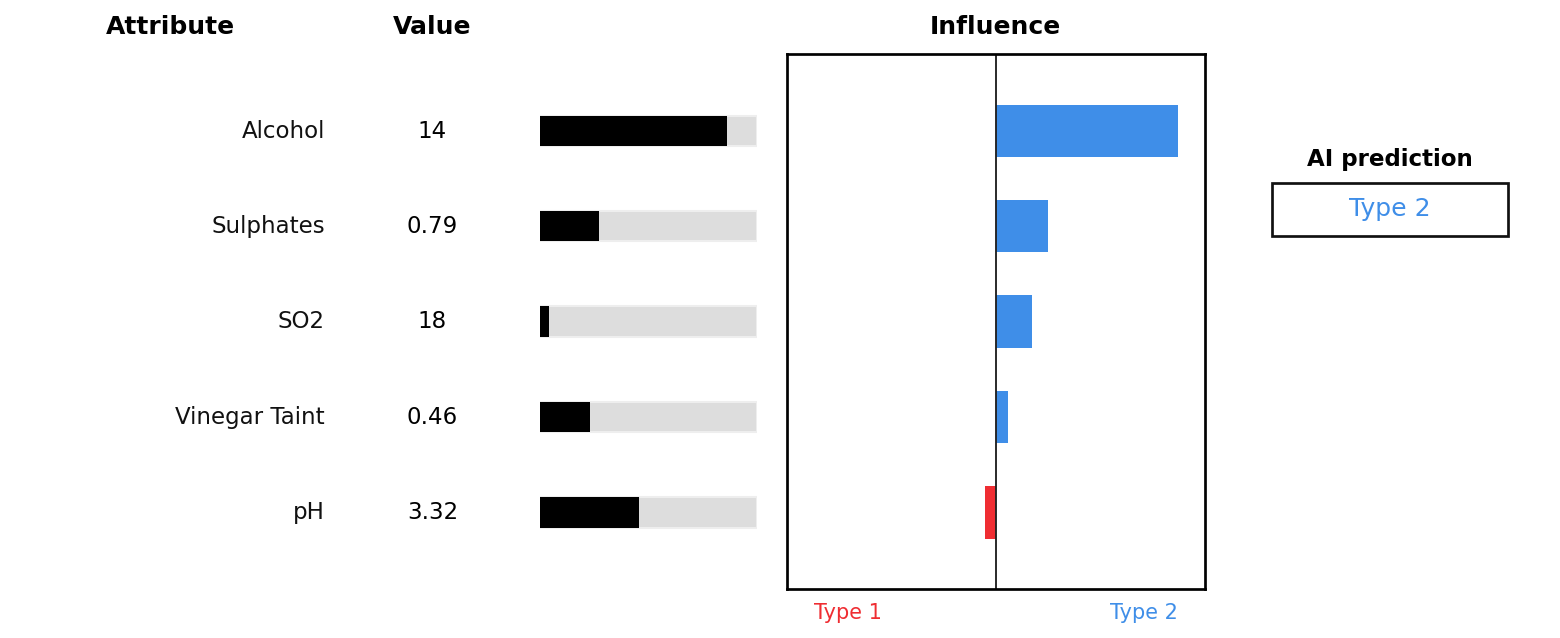
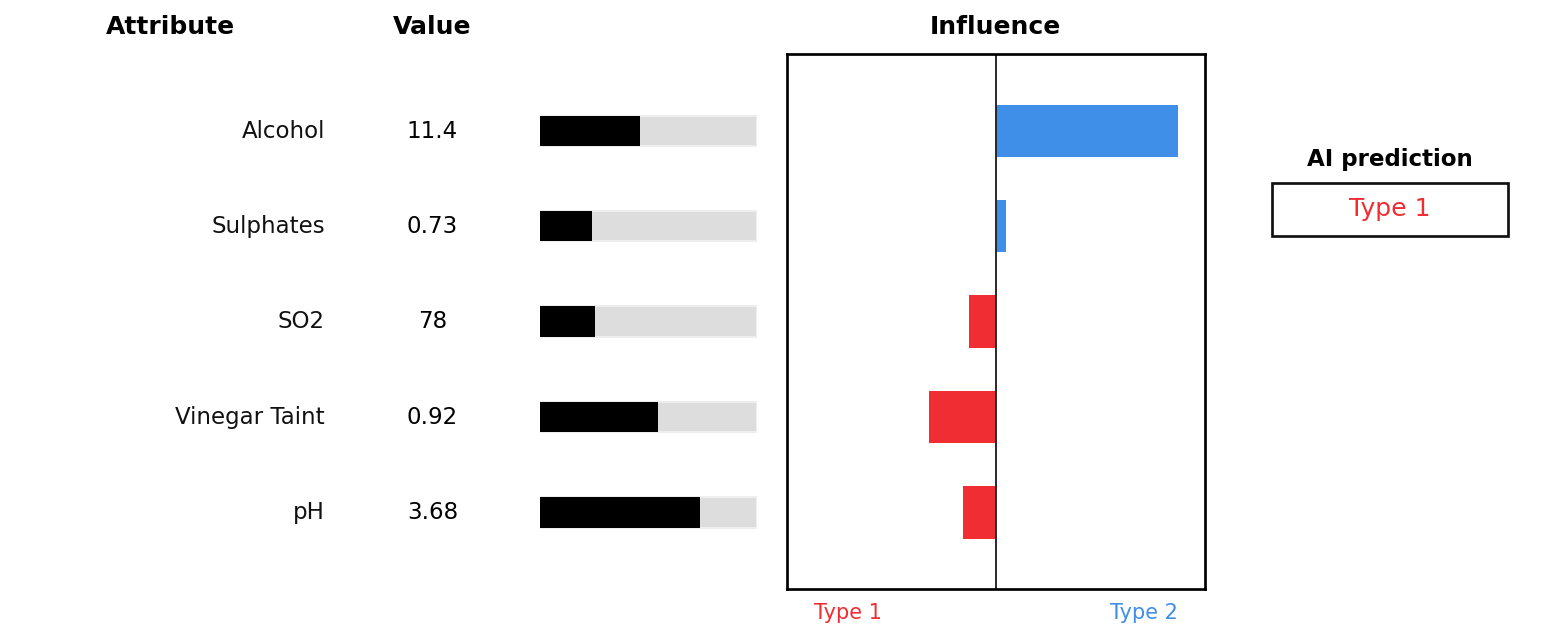
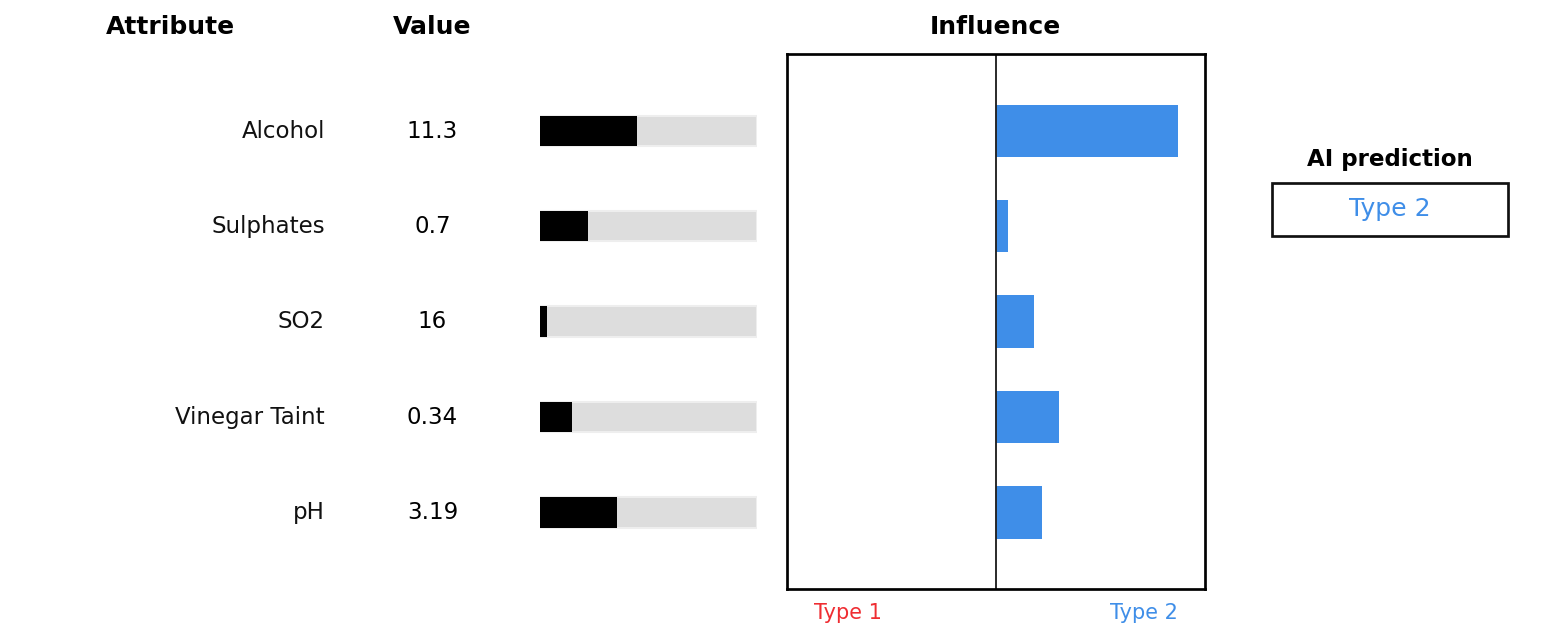
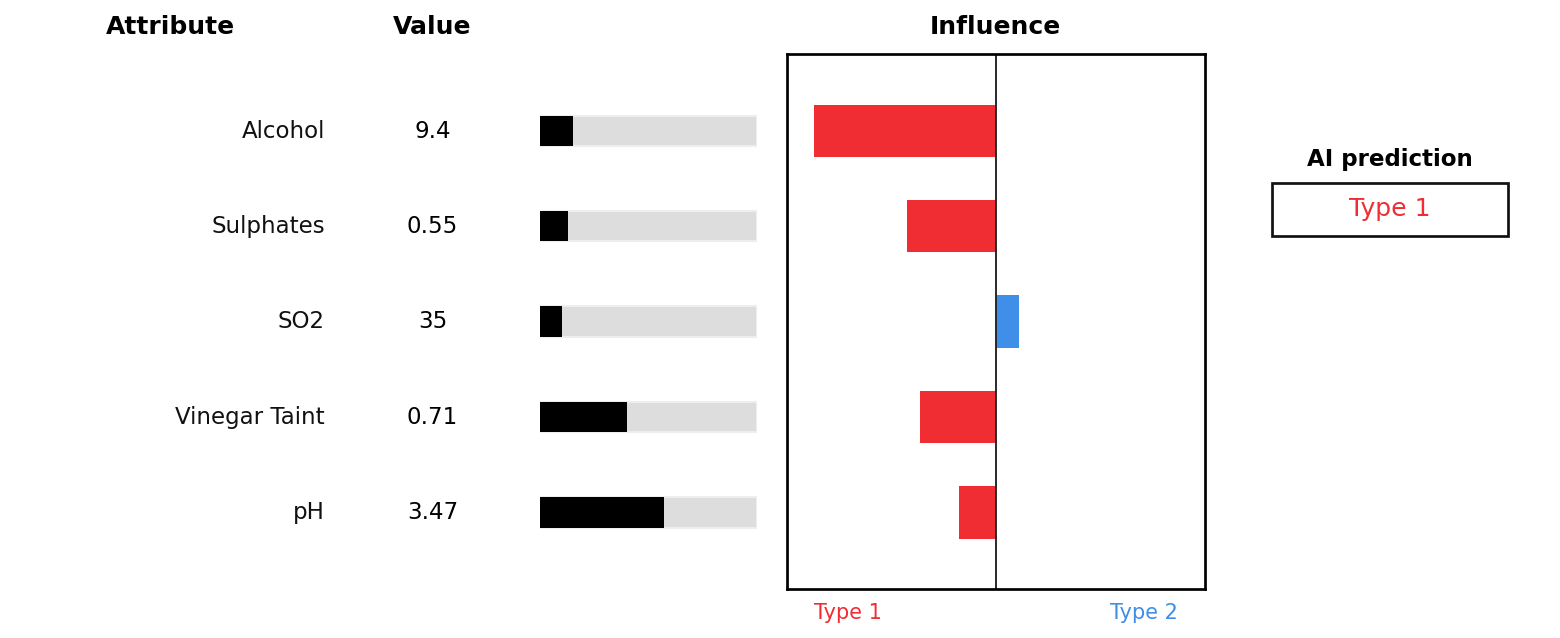
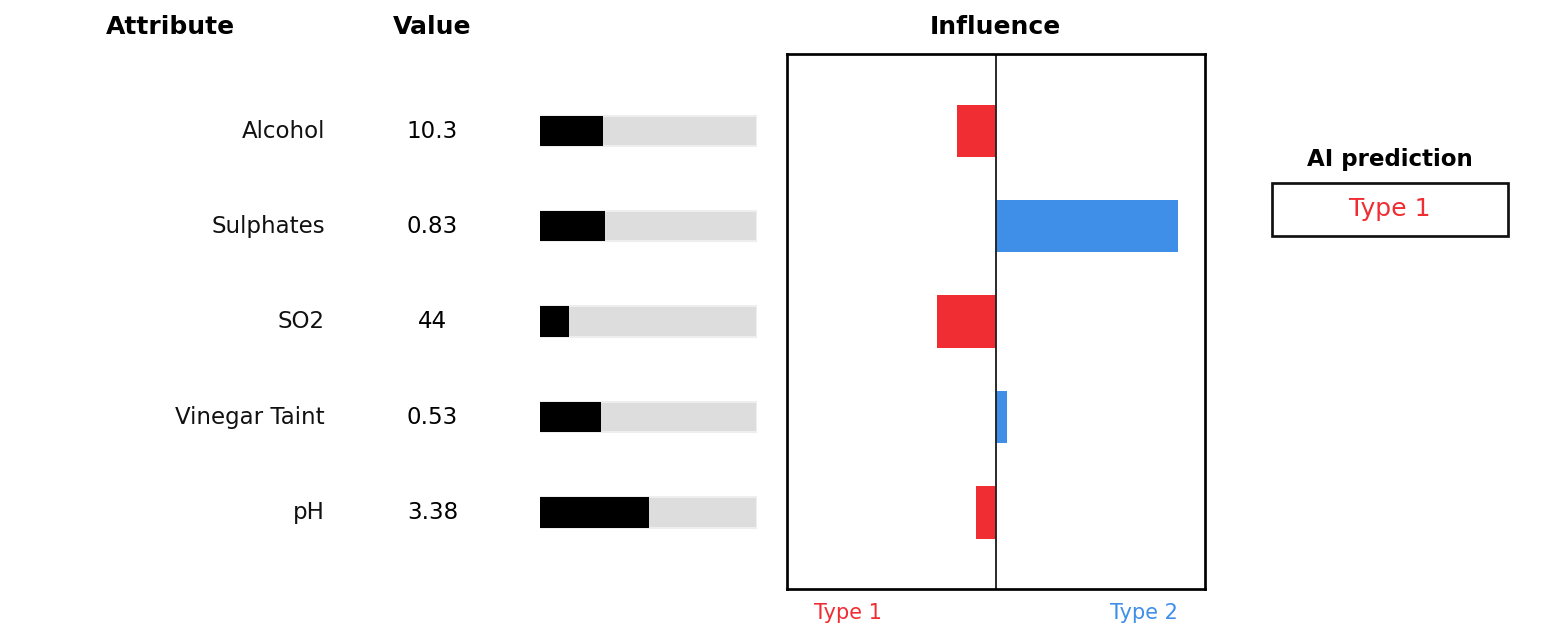
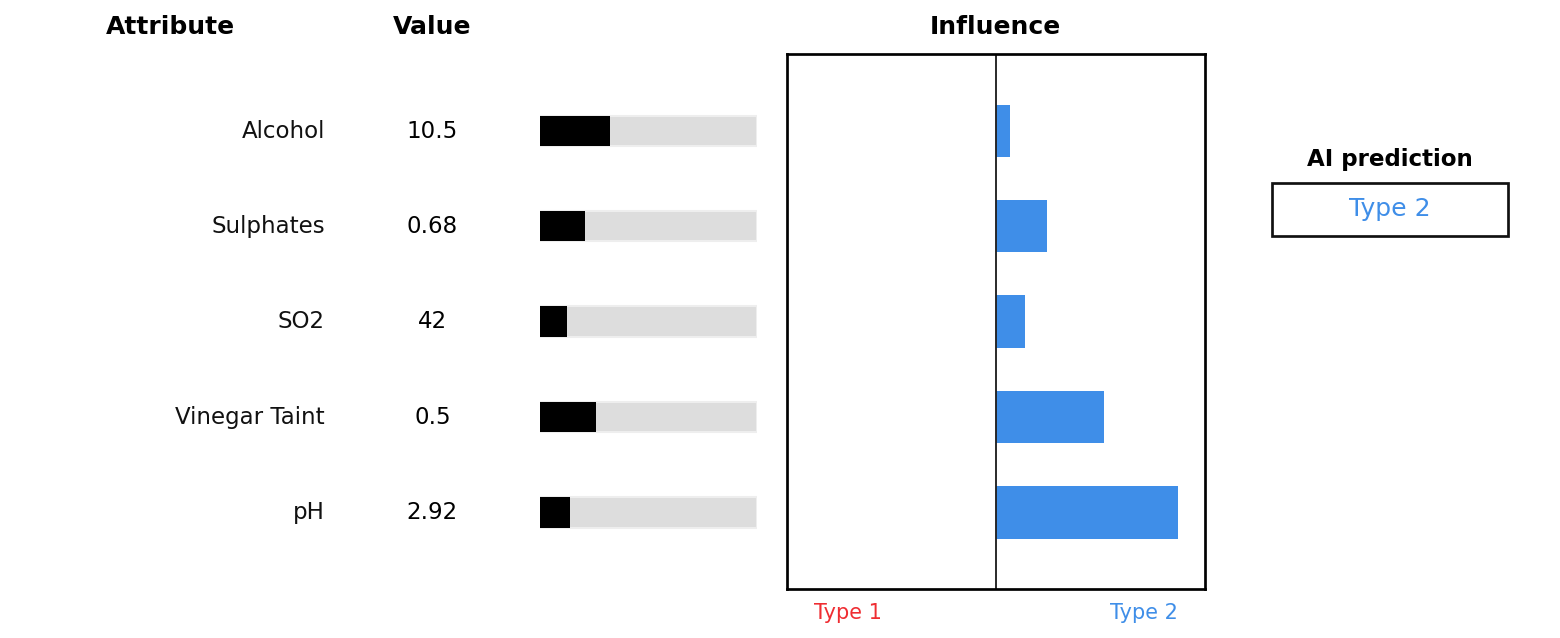
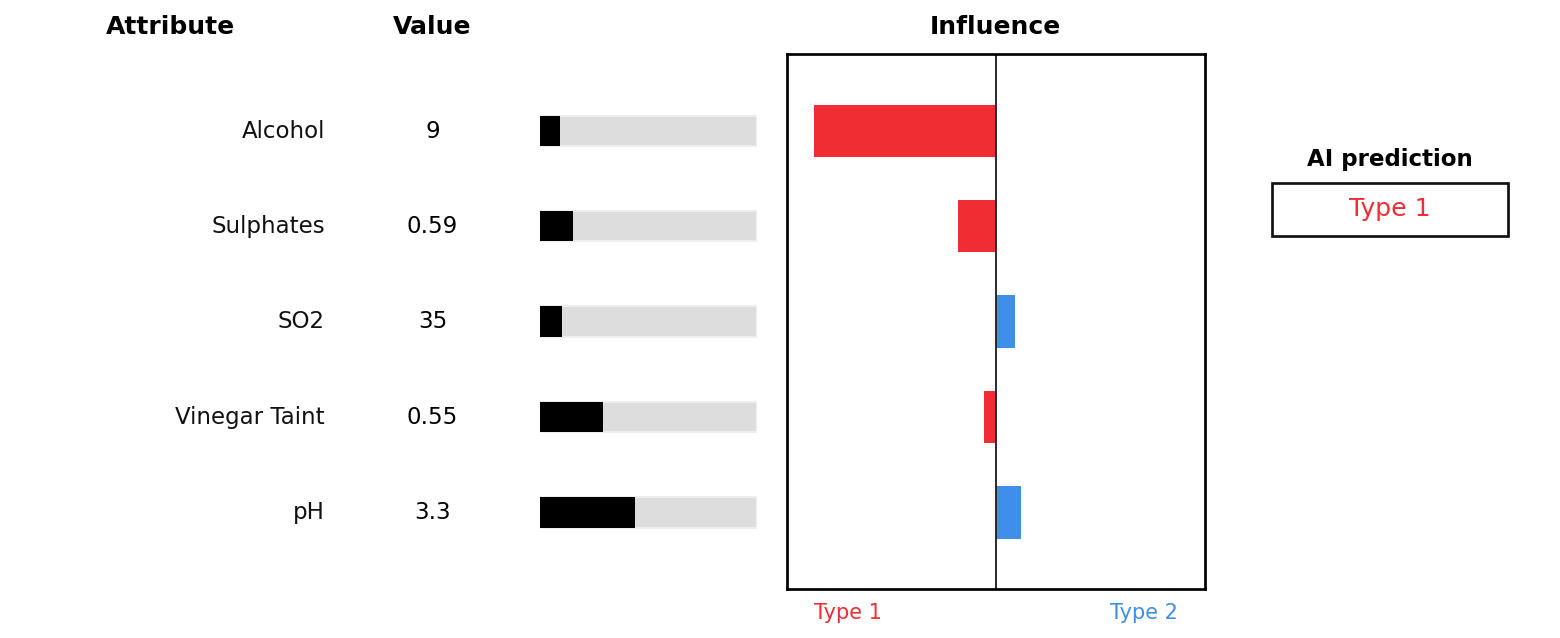
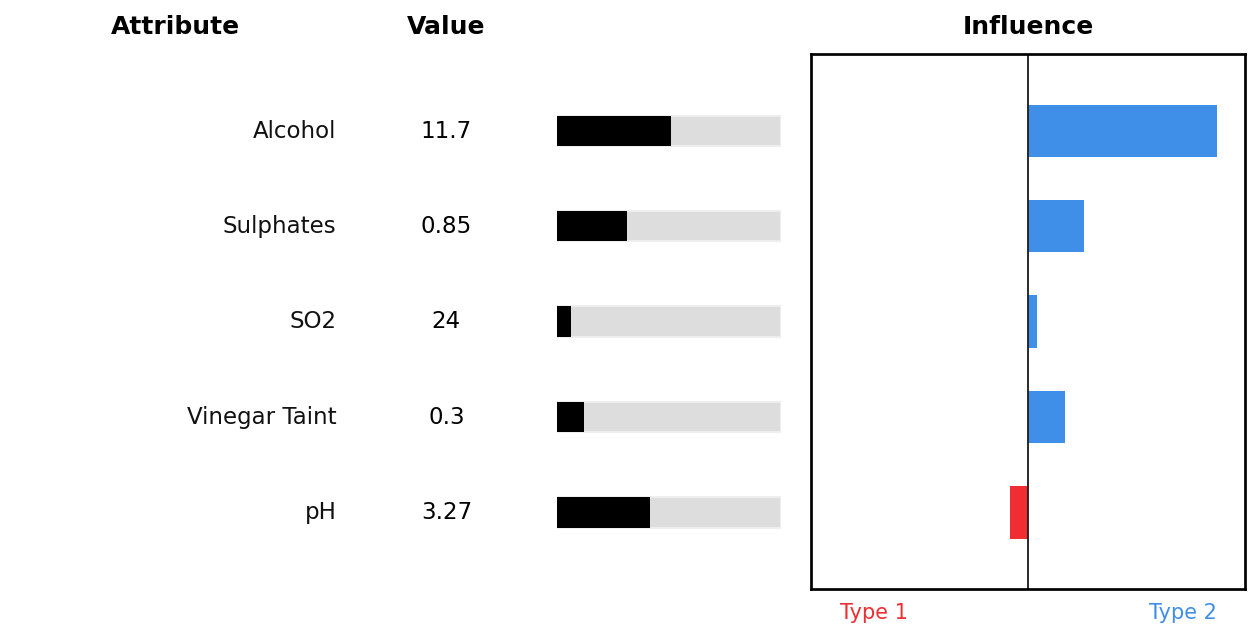
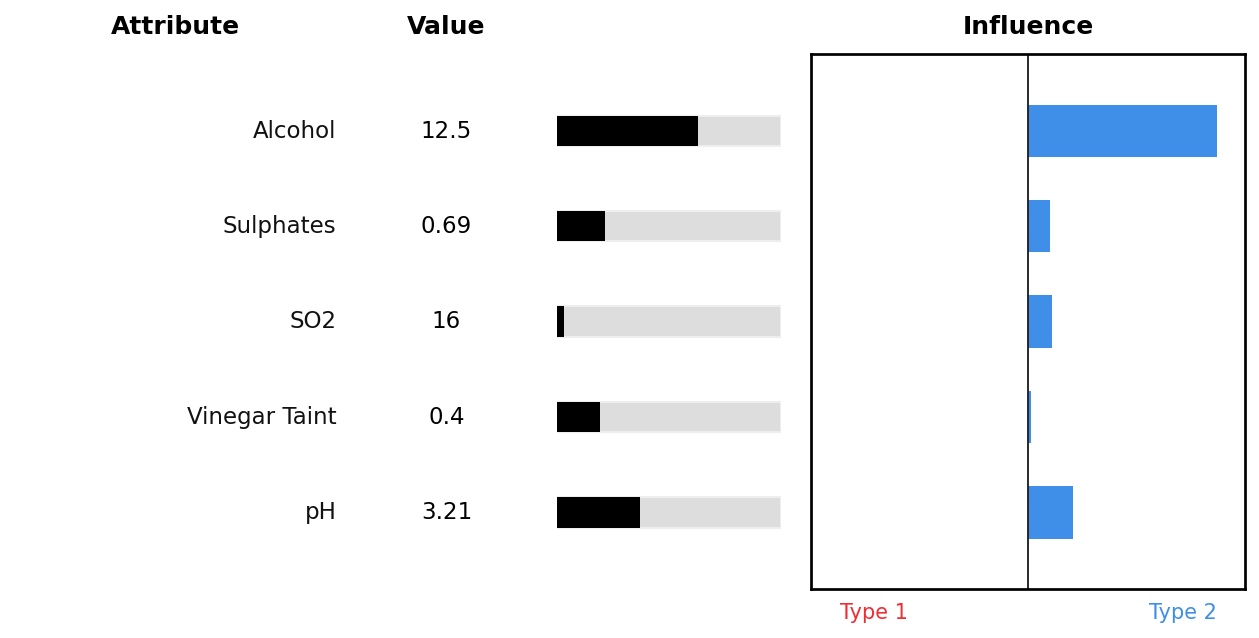
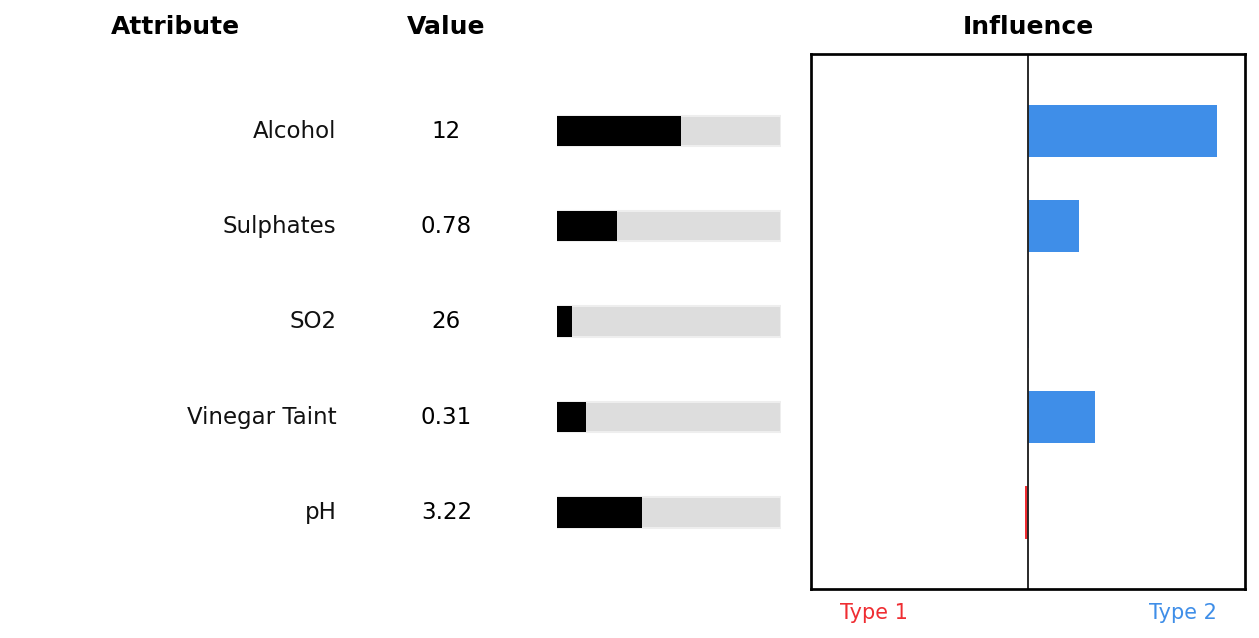
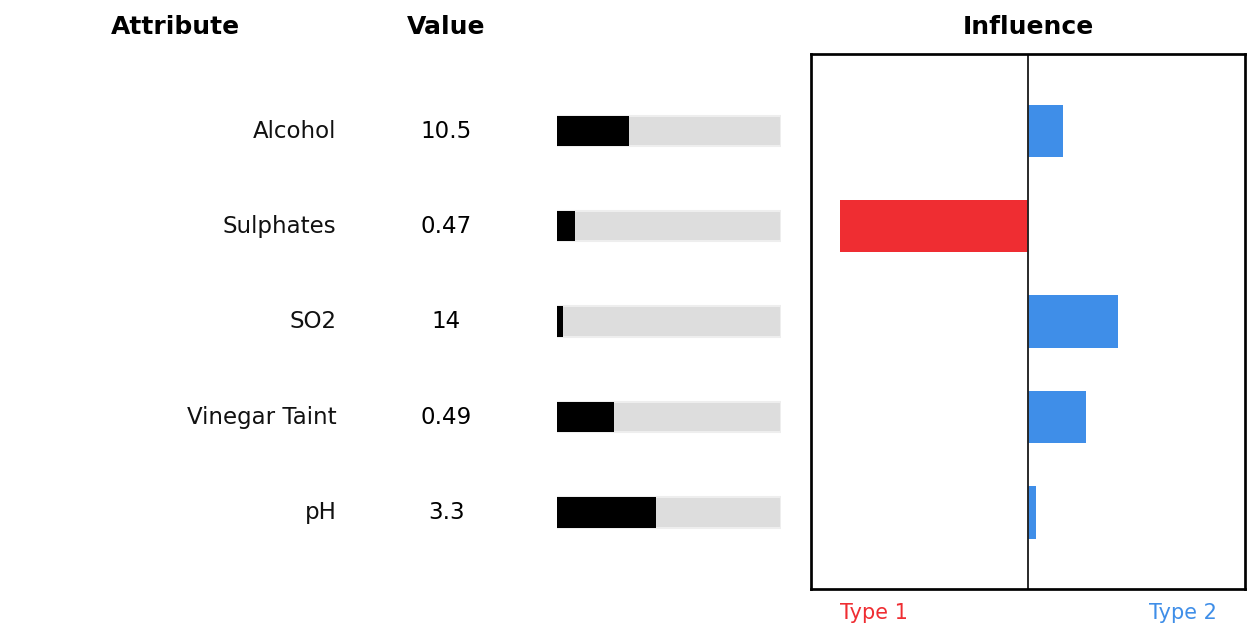
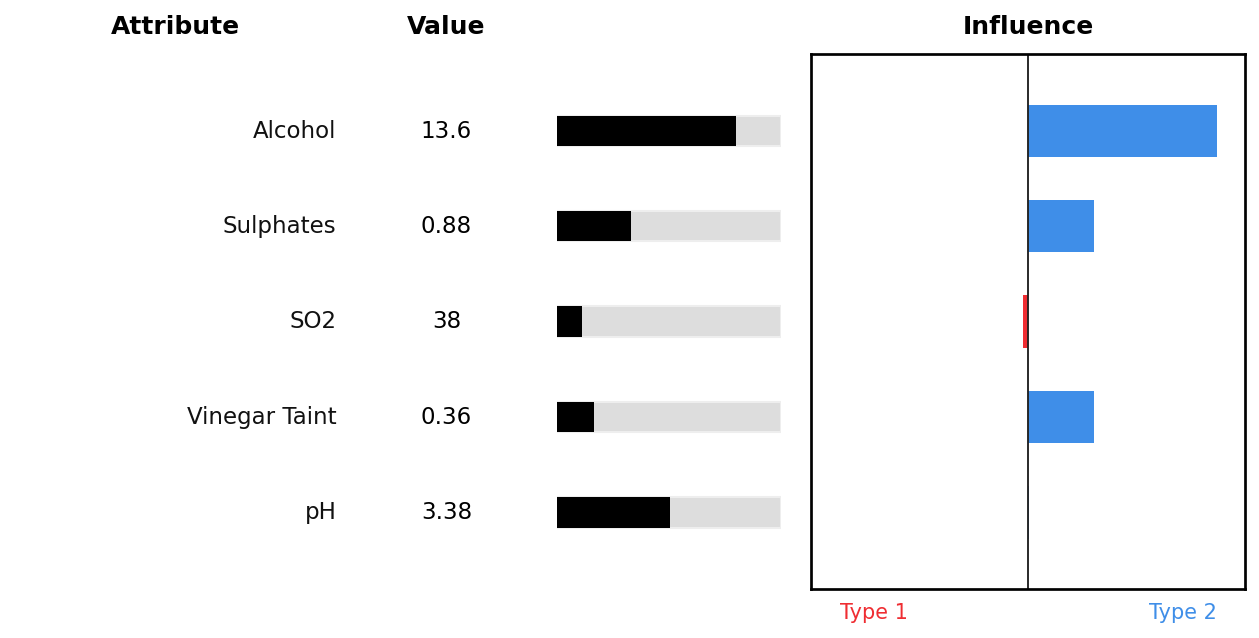
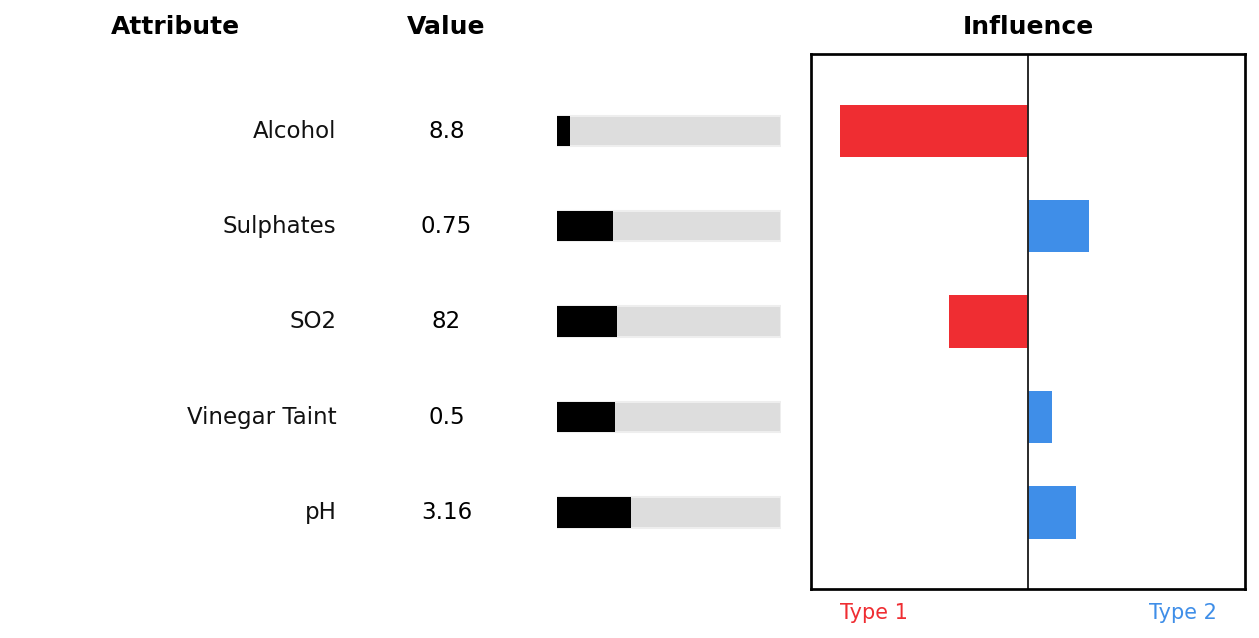
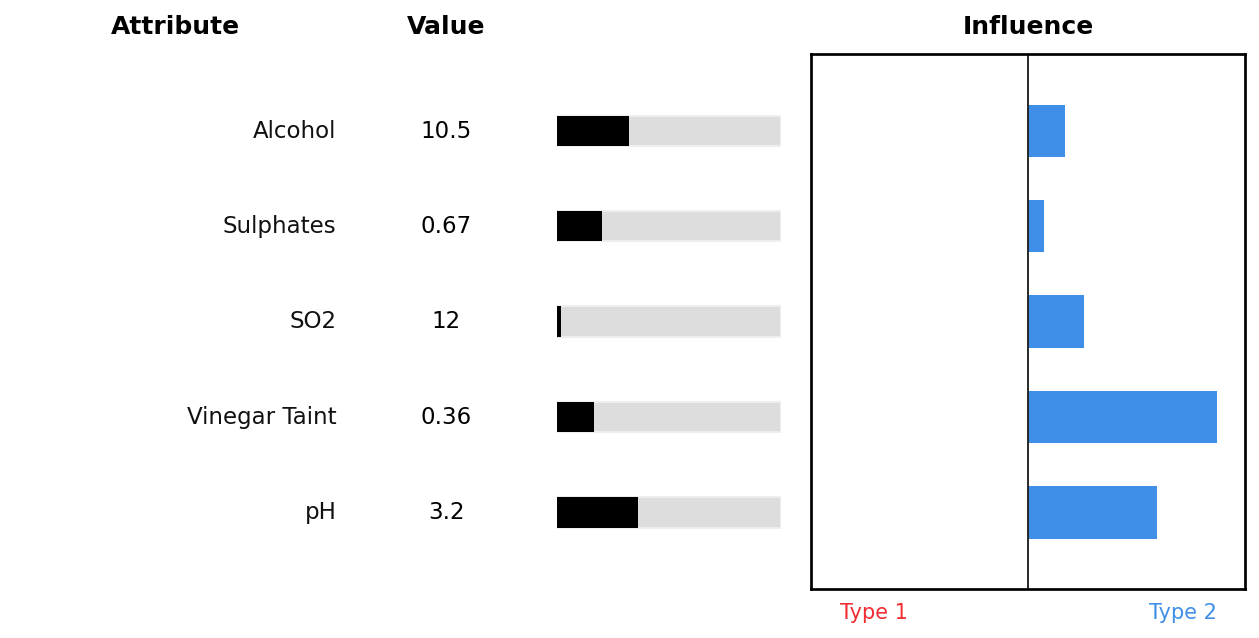
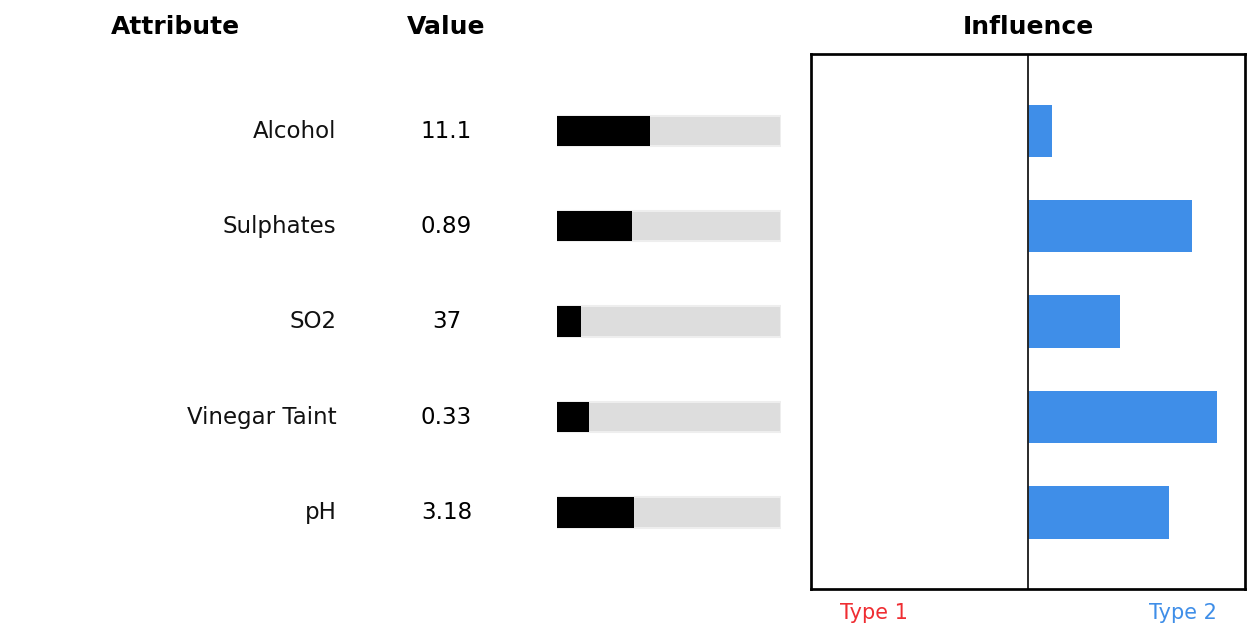
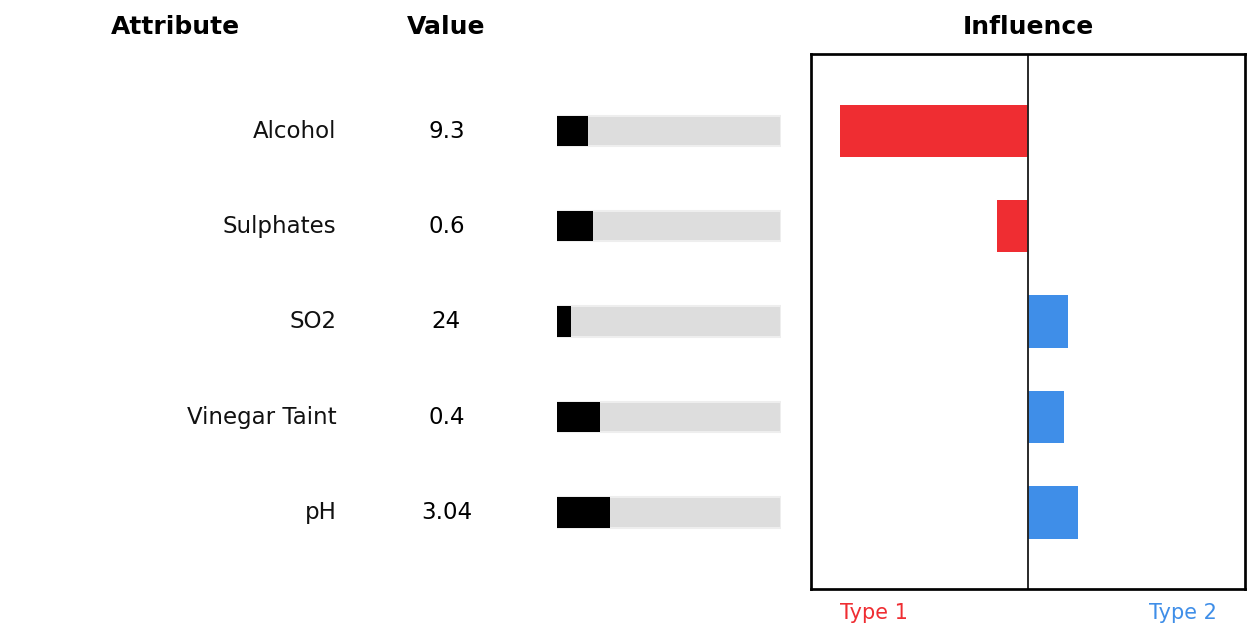
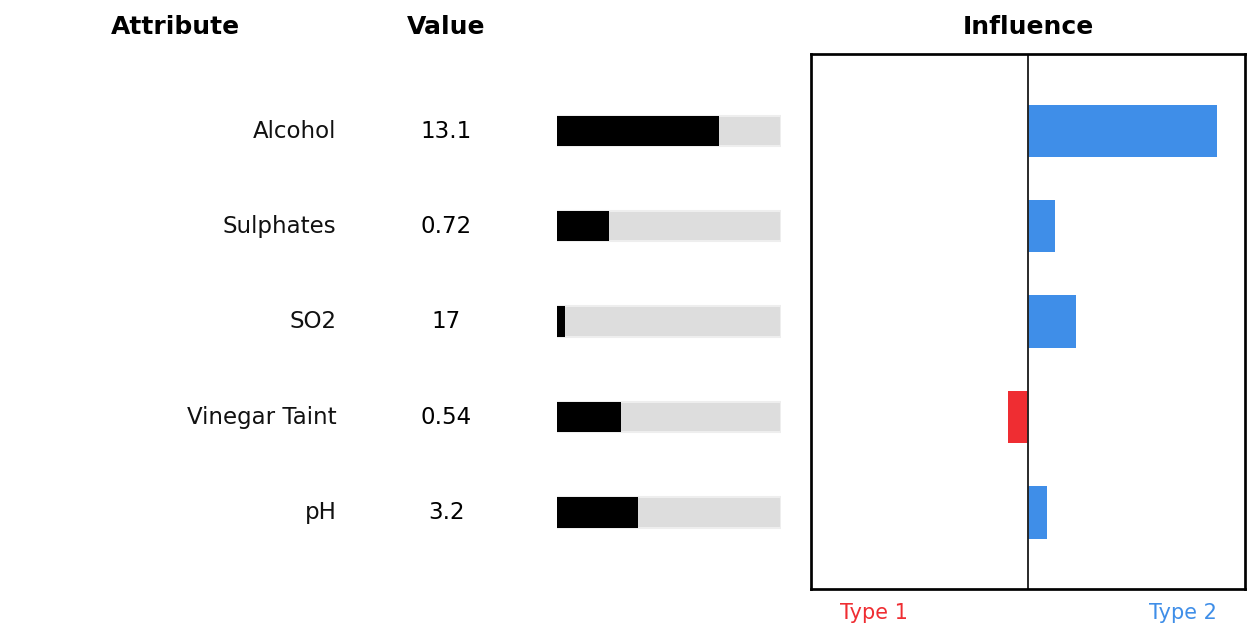

In [30]:
preview_id = int(trials.loc[trials['xai_type'].eq('attribution'), 'participantId'].iloc[0])
participant_trials = study.preview_participant_trials(
    participant_id=preview_id,
    visualization='influence',
    class_labels=['Type 1', 'Type 2'],
    fallback='html',
)

## 8. Run the virtual study

Run every participant-condition and keep the testing responses for analysis.

In [31]:
simulated_results = study.run_experiment(
    mode='whole_experiment',
    participant_id=None,
    explanation_pool=prediction_pool,
)
testing_results = simulated_results.query("phase == 'testing'").copy()
display(testing_results.head())

,participantId,trialId,block,trialWithinBlock,withinCondition,xai_type,dataId,instanceId,CV_user_task_levels,CV_num_attributes_shown_levels,...,pred_time,cognitive_correct_vs_ai,exp_a0_i,exp_a1_i,exp_a2_i,exp_a3_i,exp_a4_i,exp_pred,exp_i_max,exp_intercept
10,1,11,1,1,single_condition,none,wine_quality,505,forward_simulation,5,...,0.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,1,12,1,2,single_condition,none,wine_quality,578,forward_simulation,5,...,0.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,1,13,1,3,single_condition,none,wine_quality,999,forward_simulation,5,...,0.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,1,14,1,4,single_condition,none,wine_quality,267,forward_simulation,5,...,0.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,1,15,1,5,single_condition,none,wine_quality,940,forward_simulation,5,...,0.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Save the results

Export the trial-level responses before plotting.

In [32]:
csv_path, json_path = study.save_results(out_dir='simulated_results')
print(f'Saved {len(simulated_results):,} responses to {csv_path} and {json_path}')

Saved 720 responses to /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output/simulated_results/simulated_results.csv and /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output/simulated_results/simulated_results.json


## 9. Plot the DV against both IVs

Use one grouped bar chart to compare explanation presence and explanation type.

### Create the two-IV plot

The x-axis shows explanation presence. Bar colors show `none`, `importance`, and `attribution`.

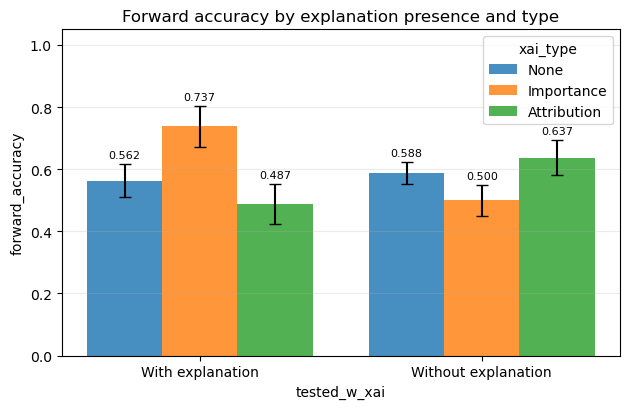

In [35]:
from src.result_visualizer import plot_dv_by_two_ivs

accuracy_plot = plot_dv_by_two_ivs(
    testing_results,
    x_iv='tested_w_xai',
    hue_iv='xai_type',
    dv='forward_accuracy',
    phase='testing',
    x_levels=[True, False],
    hue_levels=['none', 'importance', 'attribution'],
    x_labels={True: 'With explanation', False: 'Without explanation'},
    hue_labels={
        'none': 'None',
        'importance': 'Importance',
        'attribution': 'Attribution',
    },
    title='Forward accuracy by explanation presence and type',
)
accuracy_plot.figure;

### Inspect the plotted values

Check the participant-level group means and uncertainty used in the chart.

In [36]:
display(accuracy_plot.summary)

,x_iv,hue_iv,dv,index,x_level,hue_level,count,mean,std,sem
0,tested_w_xai,xai_type,forward_accuracy,0,False,attribution,8,0.6375,0.159799,0.056497
1,tested_w_xai,xai_type,forward_accuracy,1,False,importance,8,0.5000,0.141421,0.050000
2,tested_w_xai,xai_type,forward_accuracy,2,False,none,8,0.5875,0.099103,0.035038
3,tested_w_xai,xai_type,forward_accuracy,3,True,attribution,8,0.4875,0.180772,0.063913
4,tested_w_xai,xai_type,forward_accuracy,4,True,importance,8,0.7375,0.184681,0.065295
5,tested_w_xai,xai_type,forward_accuracy,5,True,none,8,0.5625,0.150594,0.053243


## 10. Test pairwise condition differences

Compare all six condition means. Holm correction controls for multiple comparisons.

In [37]:
from src.statistical_analyst import pairwise_condition_tests

pairwise_results = pairwise_condition_tests(
    testing_results,
    value_col='forward_accuracy',
    condition_cols=['xai_type', 'tested_w_xai'],
    participant_col='participantId',
    correction='holm',
)

display(pairwise_results.table.round(4))

,condition_a,condition_b,test,n_a,n_b,mean_a,mean_b,mean_difference,statistic,p_value,p_value_corrected,reject_null
0,xai_type=none | tested_w_xai=False,xai_type=none | tested_w_xai=True,paired_t,8,8,0.5875,0.5625,0.0250,0.3568,0.7318,1.0000,False
1,xai_type=none | tested_w_xai=False,xai_type=importance | tested_w_xai=False,welch_t,8,8,0.5875,0.5000,0.0875,1.4331,0.1763,1.0000,False
2,xai_type=none | tested_w_xai=False,xai_type=importance | tested_w_xai=True,welch_t,8,8,0.5875,0.7375,-0.1500,-2.0242,0.0686,0.8230,False
3,xai_type=none | tested_w_xai=False,xai_type=attribution | tested_w_xai=False,welch_t,8,8,0.5875,0.6375,-0.0500,-0.7521,0.4669,1.0000,False
4,xai_type=none | tested_w_xai=False,xai_type=attribution | tested_w_xai=True,welch_t,8,8,0.5875,0.4875,0.1000,1.3720,0.1977,1.0000,False
5,xai_type=none | tested_w_xai=True,xai_type=importance | tested_w_xai=False,welch_t,8,8,0.5625,0.5000,0.0625,0.8557,0.4066,1.0000,False
6,xai_type=none | tested_w_xai=True,xai_type=importance | tested_w_xai=True,welch_t,8,8,0.5625,0.7375,-0.1750,-2.0771,0.0575,0.7470,False
7,xai_type=none | tested_w_xai=True,xai_type=attribution | tested_w_xai=False,welch_t,8,8,0.5625,0.6375,-0.0750,-0.9661,0.3504,1.0000,False
8,xai_type=none | tested_w_xai=True,xai_type=attribution | tested_w_xai=True,welch_t,8,8,0.5625,0.4875,0.0750,0.9016,0.3830,1.0000,False
9,xai_type=importance | tested_w_xai=False,xai_type=importance | tested_w_xai=True,paired_t,8,8,0.5000,0.7375,-0.2375,-2.8879,0.0234,0.3274,False


### Read the table

- `mean_difference`: condition A minus condition B.
- `p_value_corrected`: Holm-adjusted p-value.
- `reject_null`: `True` indicates a corrected significant difference.
- `test`: paired for repeated participants; Welch for independent participants.

## Before a human study

- Treat virtual results as a pipeline check, not evidence about people.
- Pilot the instructions, feedback, and comprehension questions.
- Freeze the stimuli, exclusions, sample size, and analysis plan.
- Obtain ethics approval and informed consent.